# Identifying Deepfakes: A Data Mining Approach

**Author:** Gage Mariano | **Course:** Data Mining & Analysis

---

## Overview

Deepfakes, AI-generated images indistinguishable from genuine photographs, are no longer a theoretical threat. In 2023, a deepfake image of an [explosion at the Pentagon](https://apnews.com/article/pentagon-explosion-misinformation-stock-market-ai-96f534c790872fde67012ee81b5ed6a4) briefly crashed the stock market. In the same year, a Hong Kong finance worker was [scammed out of \$25 million](https://edition.cnn.com/2024/02/04/asia/deepfake-cfo-scam-hong-kong-intl-hnk/index.html) after a video call with deepfaked executives. And with consumer tools like Grok making face generation trivially easy, the volume of synthetic media, and the malacious potential it carries, is exploding. And the rate of these incidents will likely accelerate as newer, more powerful models release.

Which leads to the core challenge of not just *detecting* deepfakes but doing so in an **adversarial landscape** where generators evolve. The longer the discriminator takes to evolve widens the window for bad actors to wreak havoc.

To solve this problem, this project investigates whether **unsupervised data mining techniques** can serve as the backbone of a **quickly adaptable** deepfake detection system. Using the [HiDF (Human-Indistinguishable Deepfake) dataset](https://dl.acm.org/doi/epdf/10.1145/3711896.3737399), we trace a three-phase experimental journey that arrives at a hybrid **"Fusion Gauntlet"** pipeline that combines deep neural embeddings with classical data mining (K-Means clustering and anomaly detection) to achieve competitive accuracy while minimizing reliance on labeled data and costly backpropogation.


## Table of Contents

1. [Setup & Environment](#setup)
2. [Introduction: Can You Spot the Fake?](#hook)
3. [Dataset Overview & Exploratory Data Analysis](#eda)
4. [Research Question & Methodology](#rq)
5. [Phase 1: Custom Autoencoder + K-Means (Failure Analysis)](#phase1)
6. [Phase 2: ResNet-18 + Random Forest (Supervised Pivot)](#phase2)
7. [Phase 3: The Fusion Gauntlet (Final Pipeline)](#phase3)
8. [Pipeline Evolution (Ablation Table)](#ablation)
9. [Answering the Research Question](#answer)
10. [Limitations & Future Work](#limitations)
11. [Conclusion](#conclusion)
12. [Collaboration Declaration & Environment](#collab)


<a name="setup"></a>
## 1. Setup & Environment

The HiDF dataset is downloaded directly from [Zenodo](https://zenodo.org/records/16140829) on first run. Subsequent runs in the same Colab session skip the download automatically if the data is already present in `/content`.


In [1]:
import os
import random
import zipfile
import warnings
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.ndimage import sobel
from scipy.optimize import linear_sum_assignment
from scipy.stats import skew, kurtosis

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import normalize, MinMaxScaler, StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, silhouette_score,
                             confusion_matrix, roc_curve)
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

REAL_IMAGE_DIR = '/content/Real-img'
FAKE_IMAGE_DIR = '/content/Image'
METADATA_PATH = '/content/metadata.csv'
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


In [2]:
# ── Dataset Download (Zenodo) ──
# Downloads only if not already present in /content (safe to re-run)
REAL_IMG_URL = 'https://zenodo.org/records/16140829/files/Real-img.zip?download=1'
FAKE_IMG_URL = 'https://zenodo.org/records/16140829/files/Fake-img.zip?download=1'
METADATA_URL = 'https://zenodo.org/records/16140829/files/metadata.csv?download=1'

def download_and_extract(url, target_dir, zip_name):
    zip_path = f'/content/{zip_name}'
    if not os.path.exists(target_dir):
        print(f"Downloading {zip_name}...")
        urllib.request.urlretrieve(url, zip_path)
        print(f"Extracting...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall('/content')
        os.remove(zip_path)
        print(f"Done: {len(os.listdir(target_dir))} files in {target_dir}")
    else:
        print(f"{target_dir} already exists, skipping download.")

download_and_extract(REAL_IMG_URL, REAL_IMAGE_DIR, 'Real-img.zip')
download_and_extract(FAKE_IMG_URL, FAKE_IMAGE_DIR, 'Fake-img.zip')

# Download metadata CSV (not zipped)
if not os.path.exists(METADATA_PATH):
    print("Downloading metadata.csv...")
    urllib.request.urlretrieve(METADATA_URL, METADATA_PATH)
    print("Done.")
else:
    print("metadata.csv already exists, skipping download.")

real_files = sorted([os.path.join(REAL_IMAGE_DIR, f) for f in os.listdir(REAL_IMAGE_DIR)
                     if f.endswith(('.jpg', '.png'))])
fake_files = sorted([os.path.join(FAKE_IMAGE_DIR, f) for f in os.listdir(FAKE_IMAGE_DIR)
                     if f.endswith(('.jpg', '.png'))])

print(f"\nReal images: {len(real_files)}")
print(f"Fake images:  {len(fake_files)}")


Extracting...
Done: 38582 files in /content/Real-img
Extracting...
Done: 31249 files in /content/Image
Done.

Real images: 38347
Fake images:  31249


<a name="hook"></a>
## 2. Introduction: Can You Spot the Fake?

The threat landscape is evolving rapidly:
- **Misinformation**: A single convincing deepfake can move markets, influence elections, or incite violence.
- **Financial fraud**: The erosion of visual and audio authenticity expands the opportunities for social engineering and corporate fraud.
- **Identity theft/Privacy concerns**: Consumer-grade tools now allow anyone to generate photorealistic faces in seconds.


**Before we dive into the technical pipeline (and to show the validity of these concerns), let us test your own intuition.** Below, we display two random face images side by side, one real, one fake. Can you tell which is which?

--Feel free to try it a few times, some images are more convincing than others, but I hope this demonstrates the potential of these models.


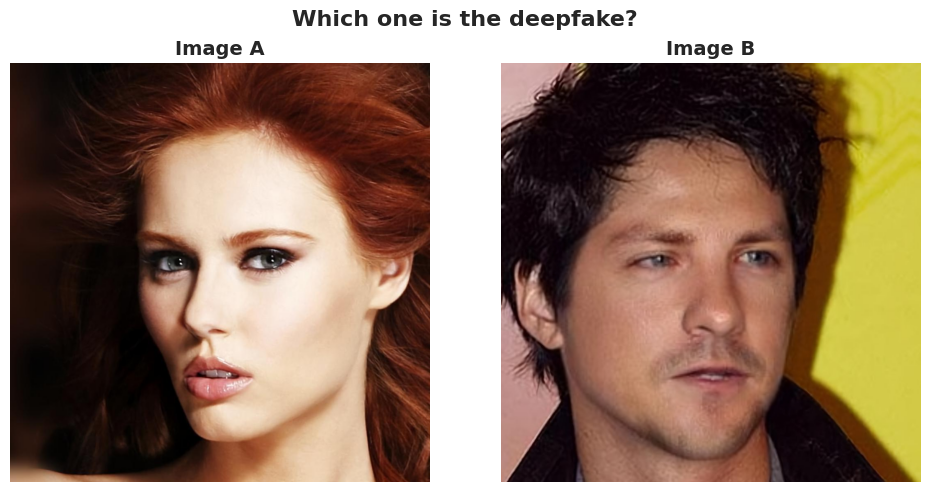

In [3]:
# ── Interactive Hook: Real vs Fake ──
if real_files and fake_files:
    hook_images = [(random.choice(real_files), "REAL"), (random.choice(fake_files), "FAKE")]
    random.shuffle(hook_images)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for i, (path, label) in enumerate(hook_images):
        axes[i].imshow(Image.open(path))
        axes[i].axis('off')
        axes[i].set_title(f"Image {'A' if i == 0 else 'B'}", fontsize=14, fontweight='bold')
    plt.suptitle("Which one is the deepfake?", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [4]:
# ── Reveal ──
if real_files and fake_files:
    for i, (path, label) in enumerate(hook_images):
        letter = 'A' if i == 0 else 'B'
        print(f"Image {letter} is: {label}")


Image A is: REAL
Image B is: FAKE


How did you do? Even if you guessed correctly, you likely weren't 100% certain, and this is while actively looking for deepfakes, without the images being cherry-picked. A sophisticated attacker will invert both of those conditions, relying on the element of surprise and perfectly curated fakes. We need a line of defense that remains constantly vigilant to catch the subtle artifacts that slip past us.

<a name="eda"></a>
## 3. Dataset Overview & Exploratory Data Analysis

### The HiDF Dataset

The **Human-Indistinguishable Deepfake (HiDF)** dataset is a curated collection of high-quality deepfake face images specifically designed to be indistinguishable from real photographs by human observers (although as you may have realized in the previous section, this is not strictly accurate). The dataset is (roughly) balanced, containing an equal number of real and fake images, and covers a variety of demographics.

Before applying any machine learning, we explore whether simple statistical properties of the images, pixel intensity, color distribution, or edge structure) can distinguish real from fake.


Total images: 69596
  Real: 38347
  Fake: 31249
  Balance ratio: 1.23


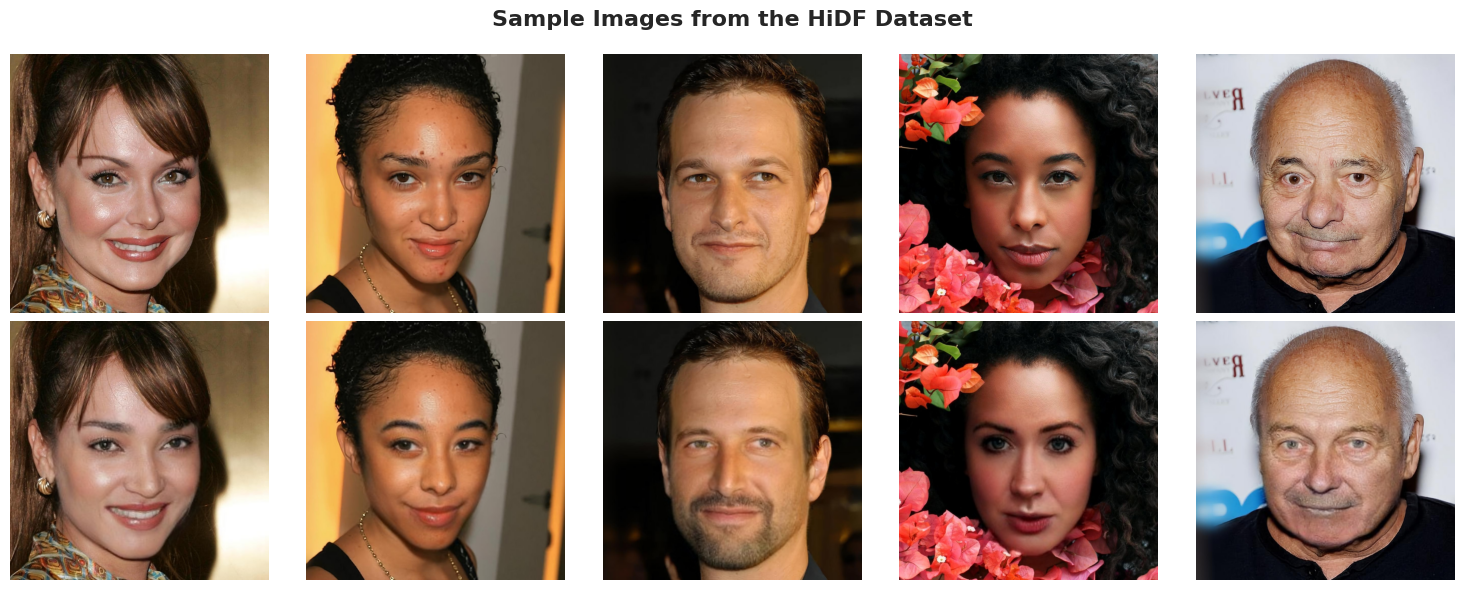

In [5]:
# ── Dataset Statistics ──
print(f"Total images: {len(real_files) + len(fake_files)}")
print(f"  Real: {len(real_files)}")
print(f"  Fake: {len(fake_files)}")
print(f"  Balance ratio: {len(real_files) / max(len(fake_files), 1):.2f}")

# Show sample grid
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    img = Image.open(real_files[i])
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel("Real", fontsize=14, fontweight='bold')
for i in range(5):
    img = Image.open(fake_files[i])
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel("Fake", fontsize=14, fontweight='bold')
plt.suptitle("Sample Images from the HiDF Dataset", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 3a. Demographic Bias Analysis

The HiDF deepfakes are generated by face-swapping: each fake image has a "base" face (the pose/background) and a "swap" face (the identity pasted on). The metadata CSV records the Age, Gender, and Race of each swap identity. Understanding the demographic distribution is important because a model trained predominantly on one subgroup may not generalize to others.


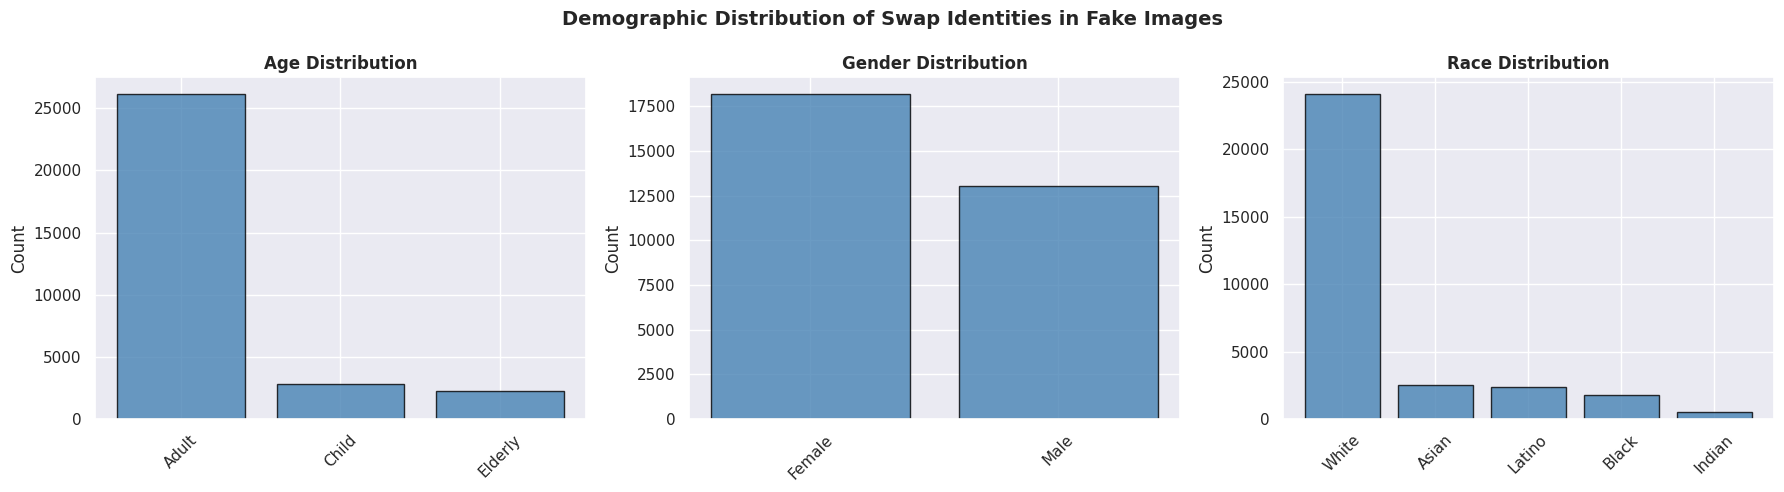

Parsed 31245 of 31249 fake images successfully.


In [6]:
# ── Demographic Bias Analysis ──
metadata_df = pd.read_csv(METADATA_PATH)

# Parse fake filenames to extract swap IDs and count demographics
fake_img_names = [os.path.basename(f) for f in fake_files]
age_counter, gender_counter, race_counter = {}, {}, {}

for fname in fake_img_names:
    try:
        ids = fname.split('.')[0].split('_')
        swap_id = ids[1].strip() if len(ids) > 1 else ids[0].strip()
        row = metadata_df.loc[metadata_df['ID'] == swap_id]
        if len(row) == 0:
            continue
        age = row['Age'].iloc[0].strip()
        gender = row['Gender'].iloc[0].strip()
        race = row['Race'].iloc[0].strip()
        age_counter[age] = age_counter.get(age, 0) + 1
        gender_counter[gender] = gender_counter.get(gender, 0) + 1
        race_counter[race] = race_counter.get(race, 0) + 1
    except Exception:
        continue

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (counter, title) in zip(axes, [
    (age_counter, "Age Distribution"),
    (gender_counter, "Gender Distribution"),
    (race_counter, "Race Distribution")
]):
    items = sorted(counter.items(), key=lambda x: x[1], reverse=True)
    labels, counts = zip(*items)
    ax.bar(labels, counts, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Demographic Distribution of Swap Identities in Fake Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Parsed {sum(age_counter.values())} of {len(fake_img_names)} fake images successfully.")


The dataset is heavily skewed toward certain demographics, primarily white adults. This imbalance is a direct reflection of the biases inherent in its foundational sources: CelebA-HQ, which draws from Western celebrity imagery, and FFHQ, which scrapes a Western-centric photography platform. Consequently, any model trained on this data will inherently require special handling to ensure generality across the different subgroups.

### 3b. Pixel Intensity Analysis

Do real and fake images differ at a basic statistical level? We compute the mean pixel intensity and per-channel (R, G, B) distributions for a random sample of images from each class.


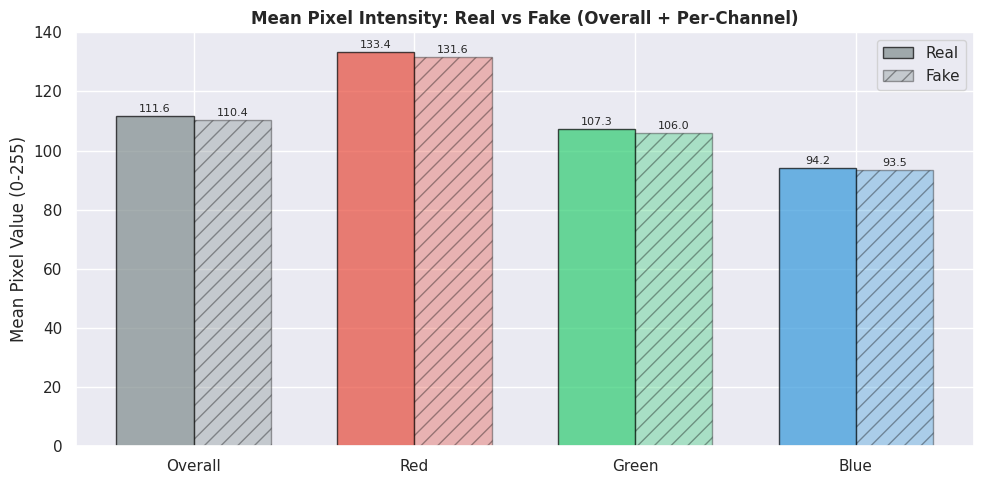

In [7]:
# ── Pixel Intensity Analysis ──
def compute_channel_intensities(files, sample_size=200):
    intensities = []
    for f in random.sample(files, min(sample_size, len(files))):
        img = np.array(Image.open(f).convert('RGB'))
        intensities.append(img.mean(axis=(0, 1)))  # Mean per channel
    return np.array(intensities)

if real_files and fake_files:
    real_intensity = compute_channel_intensities(real_files)
    fake_intensity = compute_channel_intensities(fake_files)

    # Combined bar chart: Global mean + per-channel
    channels = ['Overall', 'Red', 'Green', 'Blue']
    channel_colors = ['#7f8c8d', '#e74c3c', '#2ecc71', '#3498db']
    x = np.arange(4)
    width = 0.35

    real_means = np.concatenate([[real_intensity.mean()], real_intensity.mean(axis=0)])
    fake_means = np.concatenate([[fake_intensity.mean()], fake_intensity.mean(axis=0)])

    fig, ax = plt.subplots(figsize=(10, 5))
    bars_real = ax.bar(x - width/2, real_means, width, label='Real', color=channel_colors, alpha=0.7, edgecolor='black')
    bars_fake = ax.bar(x + width/2, fake_means, width, label='Fake', color=channel_colors, alpha=0.35, edgecolor='black', hatch='//')
    ax.set_xticks(x)
    ax.set_xticklabels(channels)
    ax.set_title("Mean Pixel Intensity: Real vs Fake (Overall + Per-Channel)", fontweight='bold')
    ax.set_ylabel("Mean Pixel Value (0-255)")
    ax.legend()

    # Annotate with exact values
    for bar in bars_real:
        ax.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
    for bar in bars_fake:
        ax.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()


Pixel intensities are nearly identical between real and fake images both globally and across all channels. This confirms that the deepfake generation process preserves macro-level image statistics almost perfectly, ruling out simple pixel-based detection. And, even if there was a significant gap, it is likely that we wouldn't want to rely too heavily on the potential heuristic as it would be very easy to correct (from the attackers perspective) and overcome.


### 3c. Gradient (Edge) Analysis

While pixel intensities are identical, deepfake generation involves "stitching" a swapped face onto a base image. This stitching process may introduce smoothing artifacts that reduce local edge sharpness. We compute Sobel gradient statistics (mean and standard deviation) for a sample of real and fake images.

**Why this matters for our pipeline:** If gradients differ between classes, the "deepfake signal" is localized (near stitching boundaries) rather than global. This means global pixel-level features will fail, but if local texture patterns could hold the key (the "deepfake" signal) to differentiation if it can be efficiently isolated (motivating our use of convolutional architectures in Phases 1 and 3).


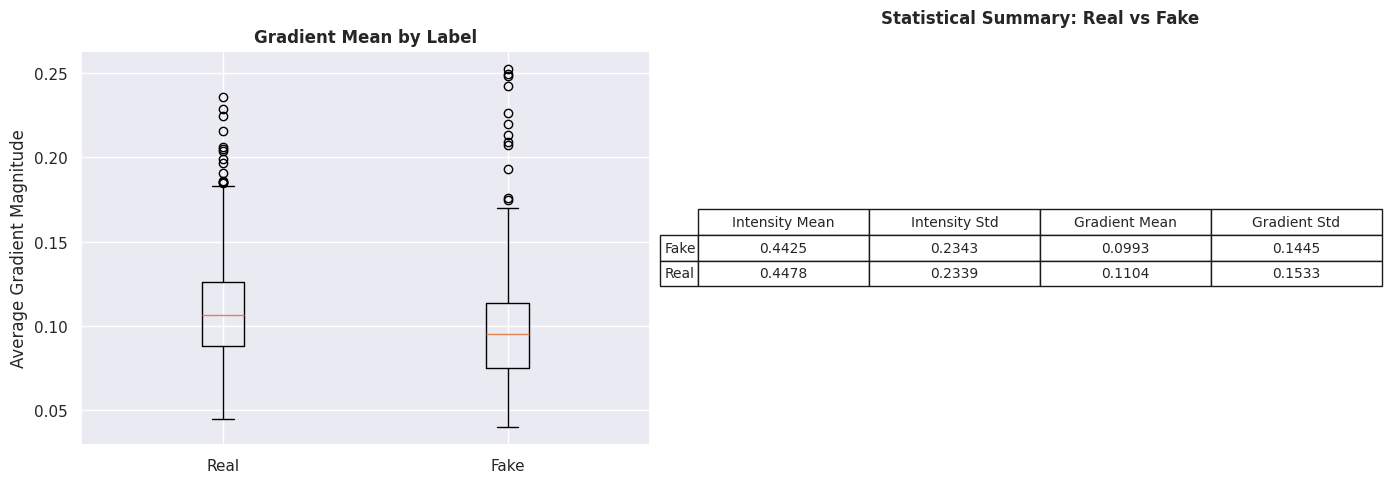

Gradient difference: Real mean = 0.1104, Fake mean = 0.0993
Fake gradients are ~10.0% lower than real.


In [8]:
# ── Gradient (Edge) Analysis ──
def convert_to_grayscale(img_array):
    if img_array.max() > 1:
        img_array = img_array / 255.0
    if img_array.ndim == 2:
        return img_array
    img_array = img_array[..., :3]
    return img_array.sum(axis=2) / 3

def get_img_stats(img_array):
    gray = convert_to_grayscale(img_array)
    stats = {}
    stats["intensity_avg"] = gray.mean()
    stats["intensity_std"] = gray.std()
    stats["intensity_skew"] = skew(gray[::4, ::4], axis=None)
    stats["intensity_kurt"] = kurtosis(gray[::4, ::4], axis=None)
    gx = sobel(gray, axis=0)
    gy = sobel(gray, axis=1)
    g = np.sqrt(gx**2 + gy**2)
    stats["grad_avg"] = g.mean()
    stats["grad_std"] = g.std()
    return stats

# Sample images for statistical analysis
EDA_SAMPLE = 300
img_stats = []

for f in random.sample(fake_files, min(EDA_SAMPLE, len(fake_files))):
    try:
        s = get_img_stats(np.array(Image.open(f).convert('RGB')).astype(float))
        s['label'] = 'Fake'
        img_stats.append(s)
    except Exception:
        pass

for f in random.sample(real_files, min(EDA_SAMPLE, len(real_files))):
    try:
        s = get_img_stats(np.array(Image.open(f).convert('RGB')).astype(float))
        s['label'] = 'Real'
        img_stats.append(s)
    except Exception:
        pass

img_stats_df = pd.DataFrame(img_stats)

# Box plot + summary table
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fake_grad = img_stats_df[img_stats_df.label == "Fake"]["grad_avg"]
real_grad = img_stats_df[img_stats_df.label == "Real"]["grad_avg"]

axes[0].boxplot([real_grad, fake_grad], labels=["Real", "Fake"])
axes[0].set_title("Gradient Mean by Label", fontweight='bold')
axes[0].set_ylabel("Average Gradient Magnitude")

summary = img_stats_df.groupby("label")[["intensity_avg", "intensity_std", "grad_avg", "grad_std"]].mean()
summary.columns = ["Intensity Mean", "Intensity Std", "Gradient Mean", "Gradient Std"]
axes[1].axis('off')
table = axes[1].table(
    cellText=summary.round(4).values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
axes[1].set_title("Statistical Summary: Real vs Fake", fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

grad_diff_pct = (real_grad.mean() - fake_grad.mean()) / real_grad.mean() * 100
print(f"Gradient difference: Real mean = {real_grad.mean():.4f}, Fake mean = {fake_grad.mean():.4f}")
print(f"Fake gradients are ~{abs(grad_diff_pct):.1f}% {'lower' if grad_diff_pct > 0 else 'higher'} than real.")


Gradients are noticeably perturbed by the deepfake process with deepfakes being noticeably smoothed. Unfortunately, this does not mean we can pack up and go home. As we mentioned and showed previously there are significant variations in the foreground and background. As a result, we cannot apply this "one-size-fits-all" heuristic globally since, for example, a black person in front of a dark background or a white person in front of a bright background could be incorrectly flagged as a deepfake. Additionally, this heuristic would be relatively simple for an attacker to correct/overcome with a sharpening filter.


### EDA Conclusions

Three key findings inform our pipeline design:

1. **Pixel intensities are identical** between real and fake images (both globally and per-channel), ruling out simple statistical detection.
2. **Gradient (edge) magnitudes differ**: fake images show a measurable decrease in average gradient, consistent with smoothing artifacts from the face-swapping "stitching" process. However, this signal is subtle and localized, meaning simple global thresholding would not be reliable.
3. **Demographic bias exists**: the dataset is skewed toward certain subgroups, which should be kept in mind when creating and evaluating the pipeline.

These results motivate our investigation into learned representations and eventually "individualized" handling. The fundamental challenge we face is a problem of scale: the forensic signal of a deepfake is extremely subtle and localized, while the natural variance in the dataset (driven by demographics, lighting, environment, etc.) is massive. If we do not account for these macro-level variations, they will easily drown out the micro-level stitching artifacts, causing a monolithic detector to overfit to demographic biases. Therefore, we need models capable of disentangling legitimate macro-features from malicious micro-anomalies. The question becomes whether we can first isolate these natural variations, allowing us to apply the appropriate process for the given variation to detect the "deepfake signal" hidden within them.


<a name="rq"></a>
## 4. Research Question & Methodology

### Research Question

> **Can unsupervised data mining techniques be used to build a quickly adaptable and accurate deepfake detector?**

Of course, even if we can build such a perfect pipeline that can catch 100% of all deepfakes created by current models, we still need to be concerned about future models. In an adversarial landscape, new deepfake generators appear regularly, and each one may produce artifacts that existing detectors have not seen. A system that requires prolonged, GPU-intensive supervised retraining on freshly labeled data is impractical. This led me to wonder if could create a pipeline where the **core detection logic is unsupervised**, so that adapting to a new generator requires only re-running lightweight (even CPU-bound) algorithms on a small sample, not retraining an entire neural network.

Note: It may seem trivial to create a new dataset of labeled data, after all we have the models available. However, you have to consider the variety of prompts, models, and weights that must be included to ensure robustness/generality. This requires significant compute time and even human oversight to ensure the quality of the dataset.

### Techniques

| Role | Technique | Why This Choice |
|------|-----------|----------------|
| **Outside Technique** | Deep Neural Encoders (ResNet-18) | Pre-trained on ImageNet, already understands visual structure. We freeze most layers to minimize supervised dependency. |
| **Course Technique 1** | K-Means Clustering | Unsupervised, fast (CPU-bound), and provides global geometric scoring via distance to real centroid. |
| **Course Technique 2** | Neural Autoencoder (Anomaly Detection) | Trained only on real data, no fake labels needed. Flags structural deviations via reconstruction error. |

Note: This is a sneak preview of the finalized techniques. The initial pipelines that you will see (which are a select subset of all the attempted pipelines) vary slightly but follow the same overarching structure.

### Methodology: Fail-Forward Iteration

Rather than presenting a single final result, this notebook documents the **iterative process** of answering our research question. Each phase directly informs the next:

1. **Phase 1**, Pure unsupervised (Custom Autoencoder + K-Means) → *Does purely unsupervised work at all?*
2. **Phase 2**, Supervised pivot (ResNet-18 + Random Forest) → *Is the problem solvable with better features?*
3. **Phase 3**, Hybrid fusion (ResNet embeddings + unsupervised K-Means + anomaly detection) → *Can we keep the features but drop the supervised classifier?*

This fail-forward approach reflects how the project evolved as initial assumptions were tested, disproven, and refined.


### 5. Phase 1: Convolutional Autoencoder + Neighborhood LOF (Failure Analysis)

Our first attempt was **fully unsupervised**: train a Convolutional Autoencoder on real images only, then use its latent space to group images into contextual neighborhoods (K-Means), and finally apply Local Outlier Factor *within each neighborhood* to flag deepfakes as local anomalies.

**The hypothesis:** Deepfakes share the same global statistics as real images (as shown in EDA), but differ in localized artifacts near the "stitching" boundaries. A CAE trained on real images should learn a "normal face" representation. K-Means would partition the latent space into contextual neighborhoods (e.g., by skin tone, lighting, age) so that LOF can compare each image against its *logical peers* rather than the entire population. A deepfake in the "young adult, neutral lighting" cluster should stand out more clearly against its neighbors than against the global average.

### Architecture
- **Encoder**: 4 convolutional layers (3 -> 16 -> 32 -> 64 -> 128 channels), stride-2 downsampling, 512D latent vector
- **Decoder**: Mirrored transposed convolutions + Sigmoid output
- **Input resolution**: 128x128
- **Training**: 10 epochs on 8,000 real images only (unsupervised, labels never seen)


In [25]:
# ── Phase 1: Dataset Preparation ──
RESOLUTION_AE = 128
transform_ae = transforms.Compose([
    transforms.Resize((RESOLUTION_AE, RESOLUTION_AE)),
    transforms.ToTensor()
])

class DeepfakeDataset(Dataset):
    """Generic dataset for loading real/fake image pairs with labels."""
    def __init__(self, real_files, fake_files, transform=None):
        min_len = min(len(real_files), len(fake_files))
        self.files = real_files[:min_len] + fake_files[:min_len]
        self.labels = [0] * min_len + [1] * min_len  # 0=Real, 1=Fake
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.files[idx]).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, self.labels[idx]
        except Exception:
            return torch.zeros((3, RESOLUTION_AE, RESOLUTION_AE)), self.labels[idx]

# Train only on real images (unsupervised: no fake images seen during training)
TRAIN_SIZE = 8000
ae_train = DeepfakeDataset(real_files[:TRAIN_SIZE], [], transform=transform_ae)

# Override: real-only loader
class RealOnlyDataset(Dataset):
    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        try:
            img = Image.open(self.files[idx]).convert('RGB')
            return self.transform(img) if self.transform else img
        except Exception:
            return torch.zeros((3, RESOLUTION_AE, RESOLUTION_AE))

real_only_dataset = RealOnlyDataset(real_files[:TRAIN_SIZE], transform=transform_ae)
ae_train_loader = DataLoader(real_only_dataset, batch_size=64, shuffle=True)

# Test set: 4000 mixed (real + fake), balanced
TEST_SIZE = 2000
ae_test_dataset = DeepfakeDataset(real_files[:TEST_SIZE], fake_files[:TEST_SIZE], transform=transform_ae)
ae_test_loader = DataLoader(ae_test_dataset, batch_size=64, shuffle=False)

print(f"CAE train set (real only): {len(real_only_dataset)}")
print(f"CAE test set (mixed): {len(ae_test_dataset)}")

CAE train set (real only): 8000
CAE test set (mixed): 4000


In [27]:
# ── Phase 1: Convolutional Autoencoder ──
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),   nn.ReLU(),  # 64x64
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  nn.ReLU(),  # 32x32
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  nn.ReLU(),  # 16x16
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),  # 8x8
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, latent_dim)
        )
        self.decoder_fc = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),  nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),   nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        latent = self.encoder(x)
        x = self.decoder_fc(latent).view(-1, 128, 8, 8)
        return self.decoder(x), latent

ae_model = ConvAutoencoder(latent_dim=512).to(device)
ae_optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)
ae_criterion = nn.MSELoss()

EPOCHS_AE = 10
ae_history = []
print("Training Convolutional Autoencoder on real images only...")
for epoch in range(EPOCHS_AE):
    ae_model.train()
    epoch_loss = 0
    for imgs in ae_train_loader:
        imgs = imgs.to(device)
        ae_optimizer.zero_grad()
        recon, _ = ae_model(imgs)
        loss = ae_criterion(recon, imgs)
        loss.backward()
        ae_optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(ae_train_loader)
    ae_history.append(avg)
    print(f"  Epoch {epoch+1:2d}/{EPOCHS_AE} | Loss: {avg:.5f}")

Training Convolutional Autoencoder on real images only...
  Epoch  1/10 | Loss: 0.04065
  Epoch  2/10 | Loss: 0.01926
  Epoch  3/10 | Loss: 0.01445
  Epoch  4/10 | Loss: 0.01195
  Epoch  5/10 | Loss: 0.01024
  Epoch  6/10 | Loss: 0.00911
  Epoch  7/10 | Loss: 0.00835
  Epoch  8/10 | Loss: 0.00768
  Epoch  9/10 | Loss: 0.00719
  Epoch 10/10 | Loss: 0.00678


Extracting CAE embeddings:   0%|          | 0/63 [00:00<?, ?it/s]

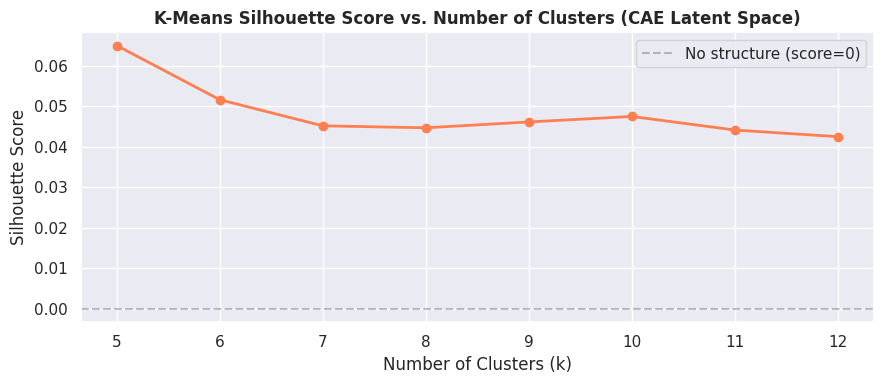

Best k: 5 | Best Silhouette Score: 0.0650
(Silhouette scores near 0 indicate no meaningful cluster structure)


In [56]:
# ── Phase 1: Extract Embeddings & K-Means Grid Search ──
ae_model.eval()
embeddings_ae, labels_ae = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(ae_test_loader, desc="Extracting CAE embeddings"):
        _, latent = ae_model(imgs.to(device))
        embeddings_ae.append(latent.cpu().numpy())
        labels_ae.extend(lbls.numpy())

X_ae = np.vstack(embeddings_ae)
y_ae = np.array(labels_ae)

# Grid search over k to find whether the latent space has ANY meaningful cluster structure
k_range = range(5, 13)
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    preds = km.fit_predict(X_ae)
    sil_scores.append(silhouette_score(X_ae, preds))

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), sil_scores, 'o-', color='coral', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5, label='No structure (score=0)')
plt.title("K-Means Silhouette Score vs. Number of Clusters (CAE Latent Space)", fontweight='bold')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.show()

best_k = k_range[int(np.argmax(sil_scores))]
best_sil = max(sil_scores)
print(f"Best k: {best_k} | Best Silhouette Score: {best_sil:.4f}")
print("(Silhouette scores near 0 indicate no meaningful cluster structure)")


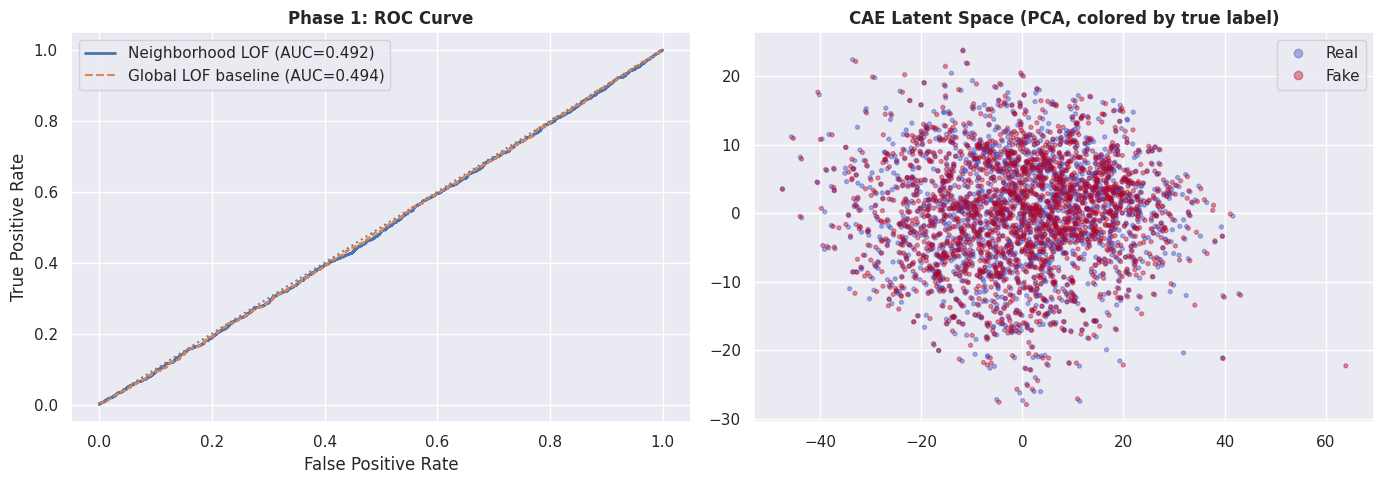

Neighborhood LOF AUC: 0.4921
Global LOF AUC: 0.4940
(Random = 0.500)


In [72]:
# ── Phase 1: Neighborhood LOF & Evaluation ──
from sklearn.neighbors import LocalOutlierFactor

# Fit K-Means with best k
kmeans_ae = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_ids = kmeans_ae.fit_predict(X_ae)

# Apply LOF locally within each cluster (the core hypothesis)
def local_lof_scores(X, cluster_ids, n_clusters, n_neighbors=20):
    scores = np.zeros(len(X))
    for c in range(n_clusters):
        idx = np.where(cluster_ids == c)[0]
        if len(idx) < n_neighbors + 1:
            continue
        lof = LocalOutlierFactor(n_neighbors=min(n_neighbors, len(idx)-1), novelty=True)
        lof.fit(X[idx])
        scores[idx] = -lof.decision_function(X[idx])
    return scores

local_scores = local_lof_scores(X_ae, cluster_ids, best_k)

# Global LOF baseline for comparison
global_lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
global_lof.fit(X_ae)
global_scores = -global_lof.decision_function(X_ae)

# ROC curves
auc_local  = roc_auc_score(y_ae, local_scores)
auc_global = roc_auc_score(y_ae, global_scores)
fpr_l, tpr_l, _ = roc_curve(y_ae, local_scores)
fpr_g, tpr_g, _ = roc_curve(y_ae, global_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr_l, tpr_l, label=f'Neighborhood LOF (AUC={auc_local:.3f})', linewidth=2)
axes[0].plot(fpr_g, tpr_g, label=f'Global LOF baseline (AUC={auc_global:.3f})', linestyle='--')
axes[0].plot([0,1],[0,1], color='gray', linestyle=':')
axes[0].set_title("Phase 1: ROC Curve", fontweight='bold')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# PCA visualization of latent space
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_ae)
scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_ae, cmap='coolwarm', alpha=0.4, s=8)
axes[1].set_title("CAE Latent Space (PCA, colored by true label)", fontweight='bold')
axes[1].legend(handles=scatter1.legend_elements()[0], labels=['Real', 'Fake'])

plt.tight_layout()
plt.show()

# Metrics for later ablation table
thresh_ae = np.percentile(local_scores, 50)
preds_ae = (local_scores > thresh_ae).astype(int)
acc_ae = accuracy_score(y_ae, preds_ae)
f1_ae = f1_score(y_ae, preds_ae)

print(f"Neighborhood LOF AUC: {auc_local:.4f}")
print(f"Global LOF AUC: {auc_global:.4f}")
print(f"(Random = 0.500)")


### Phase 1 Conclusion: Failure

The results are definitive: **the CAE-based neighborhood LOF pipeline fails to detect deepfakes.**

- **Silhouette scores near 0 across all k:** even with a grid search, the latent space produces no well-separated neighborhoods. The CAE has not learned the right kind of structure to cluster faces into meaningful contextual groups.
- **LOF AUC near 0.5:** with no usable cluster structure, local scoring performs no better than random guessing, and no better than the global LOF baseline.
- **The PCA visualization** confirms this: real and fake images are completely interleaved in the latent space with no clear clustering (based on macro features or otherwise).

**Why did this fail?** CAE likely did learn to compress toward dominant face structure, such as shape, skin tone, lighting which is exactly what we need for K-Means to form contextual neighborhoods (the low silhouette score is likely low because there are simply too many variations to capture with any reasonable k value (i.e., without reducing the clusters and increasing the runtime considerably)). But, since we see essentially random guessing, the real problem is likely that since the **deepfake stitching artifacts are high-frequency, spatially localized signals**, the bottleneck compresses them away in favor of the macro signals. So the latent vectors that reach LOF carry neighborhood information but have already lost the forensic signal we need to score anomalies.

The conclusion is not that unsupervised clustering is the wrong approach, but rather that **the custom CAE is fundamentally incapable of producing a latent space that simultaneously preserves neighborhood structure AND forensic artifacts**. To make this pipeline work, we need a feature extractor that is better suited to capture richer, more discriminative visual representations.


<a name="phase2"></a>
## 6. Phase 2: ResNet-18 + Random Forest (Supervised Pivot)

The failure of Phase 1 told us the bottleneck was the **embedding quality**, not the mining algorithm. We pivoted to using a pre-trained **ResNet-18** as the feature extractor, a network that has already learned rich visual representations from ImageNet.

### The "Extreme Neural Bottleneck" Concept

Now you're probably saying, "but wait, ResNet is a supervised encoder." And, of course, you're correct. Across the experiments with unsupervised encoding methods (of which the CAE is only one), I was unable to capture the macro-variations and micro artificats successfully. It's likely the scale between the features is simply too significant for both to be captured without the model knowing for what it is looking.

Sadly however, since images are high dimensional, we can't just completely remove encoding from the pipeline. These two facts unfortunately lead us to the need for supervised learning. So, strictly speaking, the answer to the question "Can unsupervised data mining techniques be used to build a quickly adaptable and accurate deepfake detector?" is no.
As a result, we pivot slightly, to can a more semi-supervised pipeline that heavily demphasizes the supervised aspect. We decide to use ResNet as the encoder (by removing the classification head after training) as we can leverage pre-training and since its residual connections may help to preserve minute signals (like our deepfake abberations). To reduce the relevance and the training time of this supervised aspect, rather than fine-tuning the entire ResNet (which would make the deep learning do all the work expensively), we deliberately **freeze most of the network** and let the classical data mining algorithm carry the load:

- **Frozen**: `conv1`, `bn1`, `layer1`, `layer2`, `layer3` (the majority of the network)
- **Trainable**: `layer4` + classification head (only the final convolutional block)
- **Training data**: Only **5%** of the dataset (the "handicap")

--Note: I originally tried using only the pre-trained model (no fine-tuning), but it performed very poorly, likely for the same reasons as the unsupervised approach.

This forces the ResNet to act as a fixed feature extractor with minimal fine-tuning, and puts the burden of classification on the downstream algorithm.


In [51]:
# ── Phase 2: ResNet-18 Fine-Tune (5% Handicap) + Feature Extraction ──

# Redefine dataset with resolution-aware fallback for Phase 2
class DeepfakeDataset(Dataset):
    def __init__(self, real_files, fake_files, transform=None, resolution=224):
        min_len = min(len(real_files), len(fake_files))
        self.files = real_files[:min_len] + fake_files[:min_len]
        self.labels = [0] * min_len + [1] * min_len
        self.transform = transform
        self.resolution = resolution

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.files[idx]).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, self.labels[idx]
        except Exception:
            return torch.zeros((3, self.resolution, self.resolution)), self.labels[idx]

RESOLUTION = 224
transform_resnet = transforms.Compose([
    transforms.Resize((RESOLUTION, RESOLUTION)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset_p2 = DeepfakeDataset(real_files, fake_files, transform=transform_resnet, resolution=RESOLUTION)
all_idx = list(range(len(full_dataset_p2)))
random.shuffle(all_idx)

HANDICAP = 0.05
split = int(len(all_idx) * HANDICAP)
finetune_idx = all_idx[:split]
remaining_idx = all_idx[split:]

# Proof-of-concept subset from the unseen 95%
EXTRACT_SUBSET = 10000  # ~5000 real, ~5000 fake from the unseen pool
extract_idx = random.sample(remaining_idx, min(EXTRACT_SUBSET, len(remaining_idx)))

finetune_loader = DataLoader(Subset(full_dataset_p2, finetune_idx), batch_size=32, shuffle=True)
extract_loader  = DataLoader(Subset(full_dataset_p2, extract_idx),  batch_size=64, shuffle=False)

print(f"Fine-tune pool (5%): {len(finetune_idx)} images")
print(f"Extraction subset (from 95%): {len(extract_idx)} images")

# Load ResNet-18, freeze all but layer4
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for name, param in resnet.named_parameters():
    if any(lyr in name for lyr in ['conv1', 'bn1', 'layer1', 'layer2', 'layer3']):
        param.requires_grad = False
resnet.fc = nn.Linear(512, 2)
resnet = resnet.to(device)

# Fine-tune for 1 epoch on 5% (supervised, labels used only here)
optimizer_p2 = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-4)
criterion_p2 = nn.CrossEntropyLoss()

resnet.train()
running_loss, correct, total = 0.0, 0, 0
print("Fine-tuning ResNet-18 (layer4 only, 1 epoch)...")
for imgs, lbls in tqdm(finetune_loader, desc="Fine-tuning"):
    imgs, lbls = imgs.to(device), lbls.to(device)
    optimizer_p2.zero_grad()
    out = resnet(imgs)
    loss = criterion_p2(out, lbls)
    loss.backward()
    optimizer_p2.step()
    running_loss += loss.item() * imgs.size(0)
    correct += out.argmax(1).eq(lbls).sum().item()
    total += lbls.size(0)
print(f"Fine-tune loss: {running_loss/total:.4f} | Fine-tune acc: {correct/total:.4f}")

# Swap head for feature extraction
resnet.fc = nn.Identity()
resnet.eval()

features_p2, labels_p2 = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(extract_loader, desc="Extracting 512D embeddings"):
        features_p2.append(resnet(imgs.to(device)).cpu().numpy())
        labels_p2.extend(lbls.numpy())

X_p2 = np.vstack(features_p2)
y_p2 = np.array(labels_p2)
print(f"Feature matrix: {X_p2.shape}")

Fine-tune pool (5%): 3124 images
Extraction subset (from 95%): 10000 images
Fine-tuning ResNet-18 (layer4 only, 1 epoch)...


Fine-tuning:   0%|          | 0/98 [00:00<?, ?it/s]

Fine-tune loss: 0.3913 | Fine-tune acc: 0.8262


Extracting 512D embeddings:   0%|          | 0/157 [00:00<?, ?it/s]

Feature matrix: (10000, 512)


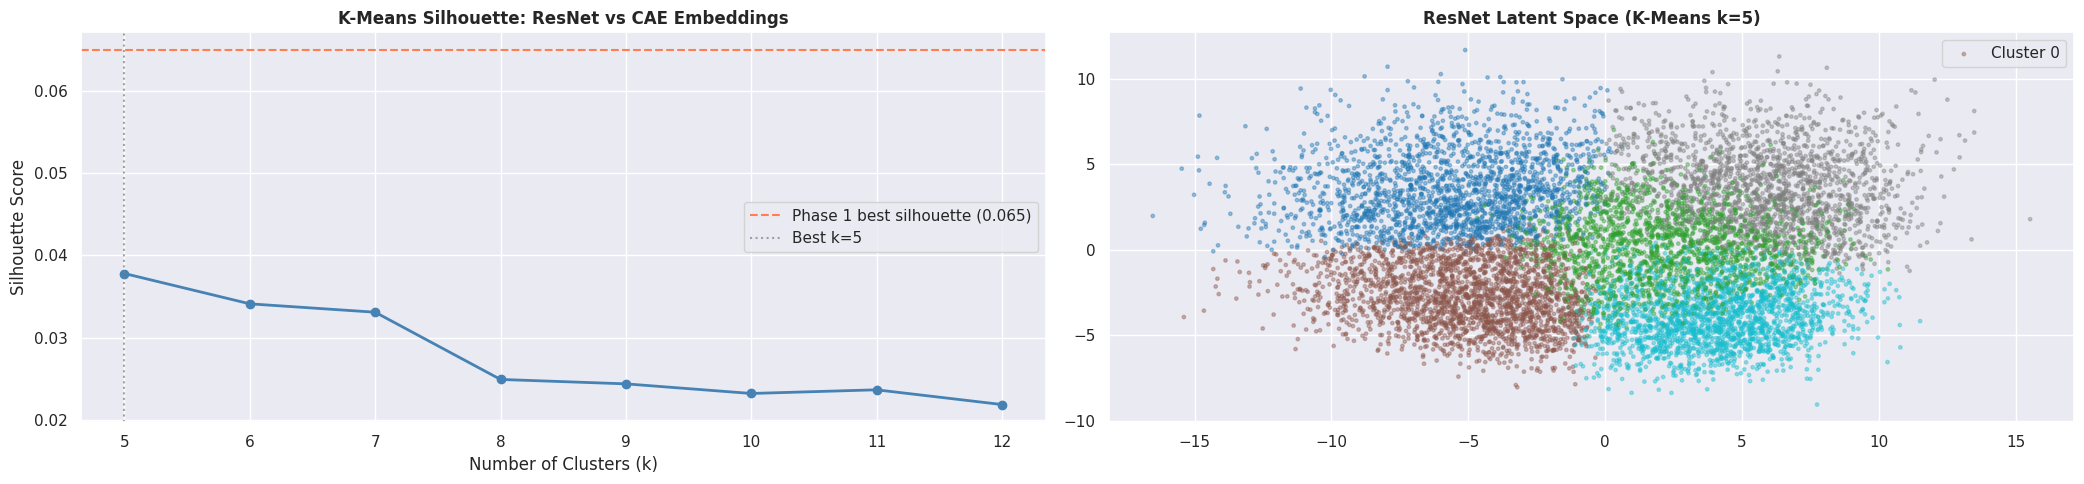

Phase 1 best silhouette (CAE embeddings):    0.0650
Phase 2 best silhouette (ResNet embeddings): 0.0378
Best k: 5

  Cluster 0:  2003 images | Real: 1896 | Fake:  107
  Cluster 1:  1795 images | Real:  580 | Fake: 1215
  Cluster 2:  2343 images | Real: 2197 | Fake:  146
  Cluster 3:  1832 images | Real:  135 | Fake: 1697
  Cluster 4:  2027 images | Real:  194 | Fake: 1833


In [61]:
# ── Phase 2: K-Means Grid Search + Embedding Visualization ──

# Grid search over same k range as Phase 1 for direct comparison
k_range = range(5, 13)
sil_scores_p2 = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    preds = km.fit_predict(X_p2)
    sil_scores_p2.append(silhouette_score(X_p2, preds))

best_k_p2  = list(k_range)[int(np.argmax(sil_scores_p2))]
best_sil_p2 = max(sil_scores_p2)

# Fit final K-Means with best k
kmeans_p2 = KMeans(n_clusters=best_k_p2, random_state=SEED, n_init=10)
cluster_ids_p2 = kmeans_p2.fit_predict(X_p2)

fig, axes = plt.subplots(1, 2, figsize=(21, 5))

# Silhouette curve
axes[0].plot(list(k_range), sil_scores_p2, 'o-', color='steelblue', linewidth=2)
axes[0].axhline(best_sil, color='coral', linestyle='--', linewidth=1.5,
                label=f'Phase 1 best silhouette ({best_sil:.3f})')
axes[0].axvline(best_k_p2, color='gray', linestyle=':', alpha=0.7,
                label=f'Best k={best_k_p2}')
axes[0].set_title("K-Means Silhouette: ResNet vs CAE Embeddings", fontweight='bold')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Silhouette Score")
axes[0].legend()

# PCA colored by K-Means cluster
scatter2 = axes[1].scatter(X_p2_2d[:, 0], X_p2_2d[:, 1], c=cluster_ids_p2,
                            cmap='tab10', alpha=0.4, s=6)
axes[1].set_title(f"ResNet Latent Space (K-Means k={best_k_p2})", fontweight='bold')
axes[1].legend(*scatter2.legend_elements(),
               labels=[f'Cluster {i}' for i in range(best_k_p2)])

plt.tight_layout()
plt.show()

print(f"Phase 1 best silhouette (CAE embeddings):    {best_sil:.4f}")
print(f"Phase 2 best silhouette (ResNet embeddings): {best_sil_p2:.4f}")
print(f"Best k: {best_k_p2}")
print()

for i in range(best_k_p2):
    mask = cluster_ids_p2 == i
    real_c = np.sum(y_p2[mask] == 0)
    fake_c = np.sum(y_p2[mask] == 1)
    print(f"  Cluster {i}: {mask.sum():5d} images | Real: {real_c:4d} | Fake: {fake_c:4d}")

### From Anomaly Detection to Random Forest

Surprisingly, the silhouette score at is comparable to Phase 1 (meaning very poor). But when we look at the split of real/fake data per cluster, we see meaningful results. Some clusters are very lopsided toward real/fake and others are more mixed. This is a critical signal: the embedding is not dead. My interpretation of these results was the maybe resnet was sorting by "difficulty" and maybe we could design unique handling for each of these clusters according to their assigned diffuclty.

However, this observation rules out anomaly detection as the per-cluster classifier. Anomaly detection assumes the target class is rare within its local population. In the lopsided clusters that assumption barely holds; in the balanced clusters it completely breaks down (LOF and Isolation Forest were tested both tested and confirm this).

For that reason, we introduce another supervised technique. **Random Forest sidesteps this issue entirely** as it makes no assumption about class rarity: it learns a discriminative boundary from labeled examples regardless of class balance. It also does not rely on backpropagation: once the ResNet embeddings are extracted, a forest trains in seconds on CPU and can be retrained from scratch with no GPU. This directly addresses the adaptability constraint from our research question. Of course there is still the remaining cost is the labeled examples themselves (which Phase 3 will address).


Cluster 0 (2003 images): Acc=0.948  AUC=0.760
Cluster 1 (1795 images): Acc=0.786  AUC=0.882

PHASE 2: ResNet + K-Means + Random Forest
Accuracy:  0.8711
AUC:       0.9414
Precision: 0.7730
Recall:    0.8902
F1 Score:  0.8275


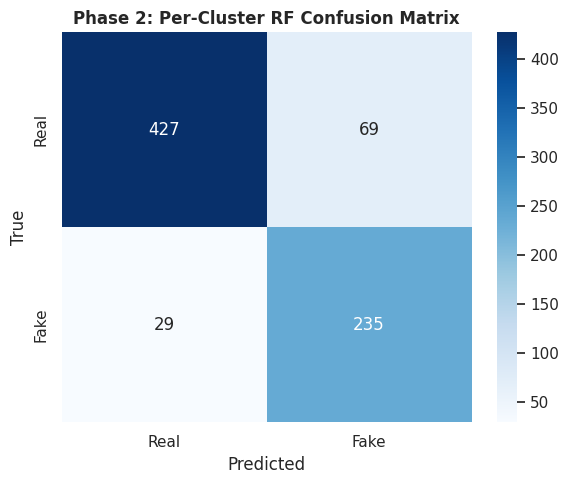

In [63]:
# ── Phase 2: Per-Cluster Random Forest Classification ──
global_y_true, global_y_pred, global_y_proba = [], [], []

for i in range(K_P2):
    mask = cluster_ids_p2 == i
    X_c = X_p2[mask]
    y_c = y_p2[mask]

    if len(np.unique(y_c)) < 2 or len(y_c) < 10:
        print(f"Cluster {i}: skipped (too small or single class)")
        continue

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_c, y_c, test_size=0.2, random_state=SEED, stratify=y_c
    )
    rf_c = RandomForestClassifier(n_estimators=100, random_state=SEED,
                                   max_depth=12, n_jobs=-1)
    rf_c.fit(X_tr, y_tr)
    y_pred_c  = rf_c.predict(X_te)
    y_proba_c = rf_c.predict_proba(X_te)[:, 1]

    local_acc = accuracy_score(y_te, y_pred_c)
    local_auc = roc_auc_score(y_te, y_proba_c)
    print(f"Cluster {i} ({mask.sum():4d} images): Acc={local_acc:.3f}  AUC={local_auc:.3f}")

    global_y_true.extend(y_te)
    global_y_pred.extend(y_pred_c)
    global_y_proba.extend(y_proba_c)

global_y_true  = np.array(global_y_true)
global_y_pred  = np.array(global_y_pred)
global_y_proba = np.array(global_y_proba)

acc_rf  = accuracy_score(global_y_true, global_y_pred)
auc_rf  = roc_auc_score(global_y_true, global_y_proba)
prec_rf = precision_score(global_y_true, global_y_pred)
rec_rf  = recall_score(global_y_true, global_y_pred)
f1_rf   = f1_score(global_y_true, global_y_pred)

print("\n" + "=" * 40)
print("PHASE 2: ResNet + K-Means + Random Forest")
print("=" * 40)
print(f"Accuracy:  {acc_rf:.4f}")
print(f"AUC:       {auc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")
print("=" * 40)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(global_y_true, global_y_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Phase 2: Per-Cluster RF Confusion Matrix", fontweight='bold')
plt.tight_layout()
plt.show()


### Phase 2 Conclusion: Success, but at what Cost

The ResNet + Random Forest pipeline achieves strong results, demonstrating that **embedding quality was indeed the bottleneck** in Phase 1. Pre-trained deep features contain enough forensic signal for classical algorithms to exploit.

However, this pipeline **contradicts our research question**: Random Forest is a **supervised** classifier that requires labeled training data and cannot adapt to new deepfake generators without collecting and labeling new examples (much more than the 5% dataset we're relying on for the encoder).

This raises the key tension of the project: *can we keep the strong embeddings but replace the supervised classifier with unsupervised techniques?*


<a name="phase3"></a>
## 7. Phase 3: The Fusion Gauntlet (Final Pipeline)
One final shift in process was required for this final pipeline. Since, I was no longer attempting to cluster by macro features but instead by difficulty, what if we return to binary classification and clustering? Previously, I had kept the minimum k relatively high since there were many variations I was trying to capture, but if I allowed k to match the binary nature of the problem, could I improve the clustering performance and make anomaly detection applicable again?

The Fusion Gauntlet answers this by combining two complementary unsupervised scoring mechanisms:

1. **Feature Extraction (Outside Technique)**: A mostly frozen ResNet-18 (unfreezing only `layer4`) extracts 512D embeddings, trained on just **5% of the data**.
2. **Macro-Scoring (Course Technique 1, K-Means)**: L2 normalization projects embeddings onto a unit hypersphere. We compute each image's distance to the "Real" centroid, fakes should be geometrically farther from this centroid.
3. **Micro-Scoring (Course Technique 2, Anomaly Detection)**: An MLP Autoencoder trained **only on real embeddings** learns the structural signature of authentic faces. Fakes produce higher reconstruction error.
4. **Fusion**: A weighted grid search combines macro and micro scores: `Final = α·Macro + (1-α)·Micro`


### 7a. Feature Extraction (ResNet-18 with Layer 4 Unfrozen)

We load a pre-trained ResNet-18 and freeze all layers except `layer4`, allowing minimal fine-tuning on a 5% subset. After training, we replace the classification head with an identity layer and extract 512D embeddings from the remaining 95%.


In [64]:
# ── Phase 3: Full Dataset with 5% Handicap ──
class DeepfakeDatasetV2(Dataset):
    """Dataset that also returns file paths (for debugging)."""
    def __init__(self, real_dir, fake_dir, transform=None):
        r = sorted([os.path.join(real_dir, f) for f in os.listdir(real_dir)
                     if f.endswith(('.jpg', '.png'))]) if os.path.exists(real_dir) else []
        f = sorted([os.path.join(fake_dir, f) for f in os.listdir(fake_dir)
                     if f.endswith(('.jpg', '.png'))]) if os.path.exists(fake_dir) else []
        min_len = min(len(r), len(f))
        r, f = r[:min_len], f[:min_len]
        self.all_files = r + f
        self.labels = [0]*len(r) + [1]*len(f)
        self.transform = transform

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.all_files[idx]).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, self.labels[idx]
        except Exception:
            return torch.zeros((3, RESOLUTION, RESOLUTION)), self.labels[idx]

full_dataset = DeepfakeDatasetV2(REAL_IMAGE_DIR, FAKE_IMAGE_DIR, transform=transform_resnet)

all_idx = list(range(len(full_dataset)))
np.random.shuffle(all_idx)

POOL_SIZE = int(len(full_dataset) * 0.05)
train_loader = DataLoader(Subset(full_dataset, all_idx[:POOL_SIZE]), batch_size=64, shuffle=True)
eval_loader = DataLoader(Subset(full_dataset, all_idx[POOL_SIZE:]), batch_size=64, shuffle=False)

print(f"Full dataset: {len(full_dataset)} images")
print(f"Training pool (5%): {POOL_SIZE} images")
print(f"Evaluation pool (95%): {len(full_dataset) - POOL_SIZE} images")


Full dataset: 62498 images
Training pool (5%): 3124 images
Evaluation pool (95%): 59374 images


In [16]:
# ── Phase 3: Train ResNet-18 (Layer 4 Unfrozen) ──
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
locked_layers = ['conv1', 'bn1', 'layer1', 'layer2', 'layer3']
for name, param in model.named_parameters():
    if any(layer in name for layer in locked_layers):
        param.requires_grad = False

model.fc = nn.Linear(512, 2)
model = model.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)
criterion = nn.CrossEntropyLoss()

EPOCHS = 5
print(f"Training ResNet-18 on {POOL_SIZE} images for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    scheduler.step()
    print(f"  Loss: {epoch_loss/len(train_loader):.4f} | Train Acc: {correct/total:.4f}")


Training ResNet-18 on 3124 images for 5 epochs...


Epoch 1/5:   0%|          | 0/49 [00:00<?, ?it/s]

  Loss: 0.3929 | Train Acc: 0.8108


Epoch 2/5:   0%|          | 0/49 [00:00<?, ?it/s]

  Loss: 0.1015 | Train Acc: 0.9702


...

  Loss: 0.0284 | Train Acc: 0.9974


Epoch 4/5:   0%|          | 0/49 [00:00<?, ?it/s]

  Loss: 0.0140 | Train Acc: 0.9997


Epoch 5/5:   0%|          | 0/49 [00:00<?, ?it/s]

  Loss: 0.0094 | Train Acc: 1.0000


In [65]:
# ── Phase 3: Extract 512D Embeddings from 95% ──
model.fc = nn.Identity()
model.eval()

embeddings, ground_truth = [], []
with torch.no_grad():
    for imgs, labels in tqdm(eval_loader, desc="Extracting 512D Embeddings"):
        latent = model(imgs.to(device))
        embeddings.append(latent.cpu().numpy())
        ground_truth.extend(labels.numpy())

embeddings = np.vstack(embeddings)
ground_truth = np.array(ground_truth)
embeddings_normed = normalize(embeddings, norm='l2')

print(f"Extracted {embeddings.shape[0]} embeddings of dimension {embeddings.shape[1]}")
print(f"  Real: {(ground_truth == 0).sum()} | Fake: {(ground_truth == 1).sum()}")


Extracting 512D Embeddings:   0%|          | 0/928 [00:00<?, ?it/s]

Extracted 59374 embeddings of dimension 512
  Real: 29747 | Fake: 29627


### 7b. Macro-Scoring: K-Means on L2-Normalized Embeddings (Course Technique 1)

L2 normalization projects all embeddings onto a unit hypersphere, making Euclidean distance mathematically equivalent to cosine similarity. We then compute a "Real centroid" and measure each image's distance to it. The intuition: fake images should be geometrically farther from the center of the "real" distribution, allowing us to take advantage of the clustering beyond just as an "initial guess" while diversifing are detection methods.


K-Means Silhouette Score: 0.2026


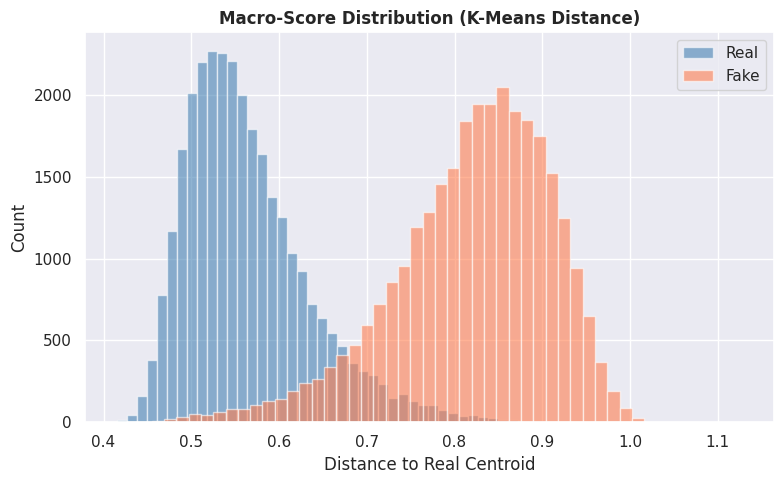

In [66]:
# ── Phase 3b: Macro-Scoring (K-Means) ──
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(embeddings_normed)

sil_fusion = silhouette_score(embeddings_normed, clusters)
print(f"K-Means Silhouette Score: {sil_fusion:.4f}")

# Compute Real Centroid
real_mask = (ground_truth == 0)
real_centroid = normalize(
    np.mean(embeddings_normed[real_mask], axis=0, keepdims=True), norm='l2'
)
macro_scores = np.linalg.norm(embeddings_normed - real_centroid, axis=1)

# Visualize macro score distributions
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(macro_scores[ground_truth == 0], bins=50, alpha=0.6, label='Real', color='steelblue')
ax.hist(macro_scores[ground_truth == 1], bins=50, alpha=0.6, label='Fake', color='coral')
ax.set_xlabel("Distance to Real Centroid")
ax.set_ylabel("Count")
ax.set_title("Macro-Score Distribution (K-Means Distance)", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### 7c. Micro-Scoring: MLP Autoencoder Anomaly Detection (Course Technique 2)

The choice of reconstruction error as the micro-scoring signal is a direct lesson from Phase 1. In Phase 1, we trained a convolutional autoencoder on real images and used its **latent vectors** for anomaly detection, and it failed, because the bottleneck compressed away the forensic signal. What Phase 1 did not test was the **reconstruction error itself**: a CAE trained only on real faces learns to decode "real face" patterns. When a fake image passes through, the decoder has no template for the generative artifacts, so the reconstruction is imperfect and the error rises since the "deepfake signal" gets compressed away.

We train a 5-layer MLP Autoencoder **strictly on real embeddings**. This model learns the "biological signature" of authentic faces. When fake embeddings pass through, the reconstruction error (MSE) spikes, flagging them as structural anomalies.


Training MLP Autoencoder on 29747 real embeddings...
  Epoch 10/30 | Loss: 0.001653
  Epoch 20/30 | Loss: 0.000717
  Epoch 30/30 | Loss: 0.000622


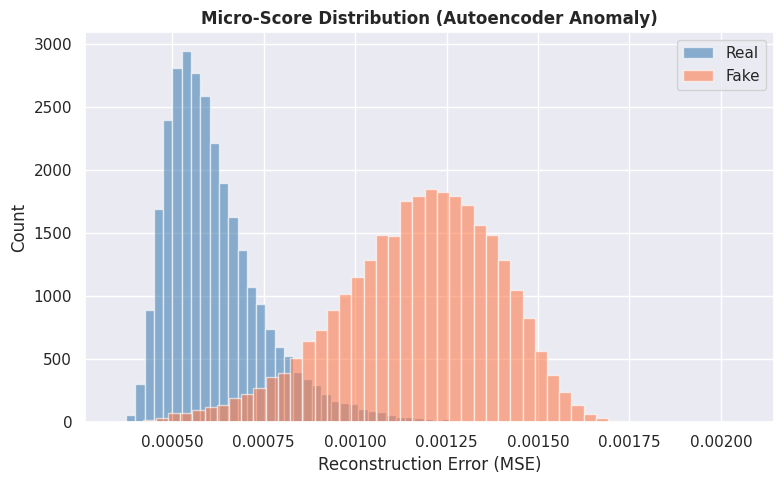

In [67]:
# ── Phase 3c: Micro-Scoring (MLP Autoencoder) ──
X_real_tensor = torch.FloatTensor(embeddings_normed[ground_truth == 0]).to(device)

ae_mlp = nn.Sequential(
    nn.Linear(512, 128), nn.ReLU(),
    nn.Linear(128, 64),
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 512)
).to(device)

ae_mlp_opt = optim.Adam(ae_mlp.parameters(), lr=1e-3)
ae_mlp_crit = nn.MSELoss()

AE_EPOCHS = 30
print(f"Training MLP Autoencoder on {X_real_tensor.shape[0]} real embeddings...")
for epoch in range(AE_EPOCHS):
    ae_mlp.train()
    ae_mlp_opt.zero_grad()
    loss = ae_mlp_crit(ae_mlp(X_real_tensor), X_real_tensor)
    loss.backward()
    ae_mlp_opt.step()
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{AE_EPOCHS} | Loss: {loss.item():.6f}")

# Score all embeddings
ae_mlp.eval()
with torch.no_grad():
    all_tensor = torch.FloatTensor(embeddings_normed).to(device)
    reconstructed = ae_mlp(all_tensor)
    micro_scores = torch.mean((all_tensor - reconstructed)**2, dim=1).cpu().numpy()

# Visualize micro score distributions
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(micro_scores[ground_truth == 0], bins=50, alpha=0.6, label='Real', color='steelblue')
ax.hist(micro_scores[ground_truth == 1], bins=50, alpha=0.6, label='Fake', color='coral')
ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_ylabel("Count")
ax.set_title("Micro-Score Distribution (Autoencoder Anomaly)", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### 7d. Fusion

Inspecting the individual score distributions, we see the histograms above show that both the macro score (K-Means distance from the real cluster centroid) and the micro score (AE reconstruction error) exhibit separation between real and fake images: the fake distribution is shifted toward higher scores in both channels. However, neither channel produces clean separation on its own, the distributions overlap significantly, but crucially **they do not fail in the exact same way**. Images that score ambiguously on the macro channel may score more decisively on the micro channel, and vice versa. This complementarity is what motivates the fusion: combining both signals into a single score should produce a distribution with stronger separation than either channel alone.

We normalize both score channels to [0, 1] using MinMaxScaler and combine them via a weighted sum:

`Final_Score = alpha * Macro_Score + (1 - alpha) * Micro_Score`

--Note: I performed grid search over alpha in practice, but there was very little difference in performance between the different values. As a result, I decided to hardcode 0.5 as it ensured that a given image would have to fool both metrics which may help generality.


In [68]:
# ── Phase 3d: Fusion & Final Results ──
scaler = MinMaxScaler()
s_macro = scaler.fit_transform(macro_scores.reshape(-1, 1)).flatten()
s_micro = scaler.fit_transform(micro_scores.reshape(-1, 1)).flatten()

ALPHA = 0.5
final_scores = ALPHA * s_macro + (1 - ALPHA) * s_micro

# Threshold at 50th percentile (balanced dataset)
thresh = np.percentile(final_scores, 50)
preds = (final_scores > thresh).astype(int)

acc_fusion  = accuracy_score(ground_truth, preds)
auc_fusion  = roc_auc_score(ground_truth, final_scores)
prec_fusion = precision_score(ground_truth, preds)
rec_fusion  = recall_score(ground_truth, preds)
f1_fusion   = f1_score(ground_truth, preds)

print("=" * 40)
print("FUSION GAUNTLET RESULTS")
print("=" * 40)
print(f"Alpha:      {ALPHA:.2f} (Macro) / {1-ALPHA:.2f} (Micro)")
print(f"Accuracy:   {acc_fusion:.4f}")
print(f"AUC:        {auc_fusion:.4f}")
print(f"Precision:  {prec_fusion:.4f}")
print(f"Recall:     {rec_fusion:.4f}")
print(f"F1 Score:   {f1_fusion:.4f}")
print("=" * 40)

FUSION GAUNTLET RESULTS
Alpha:      0.50 (Macro) / 0.50 (Micro)
Accuracy:   0.9262
AUC:        0.9736
Precision:  0.9252
Recall:     0.9270
F1 Score:   0.9261


### 7e. Final Results: Confusion Matrix & ROC Curve


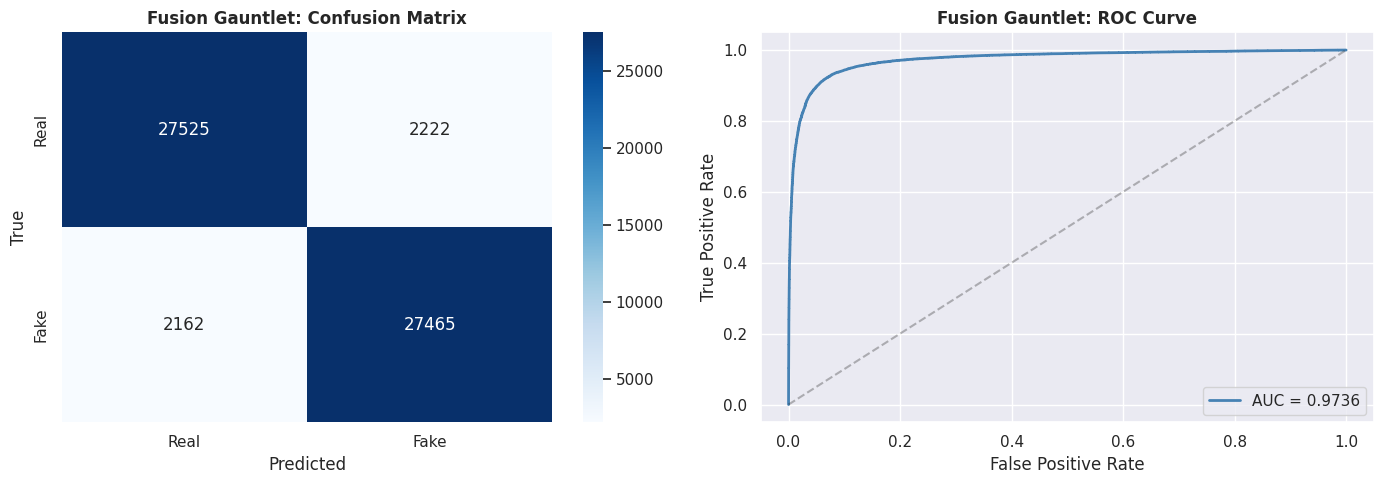

In [69]:
# ── Phase 3e: Visualize Final Results ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_fusion = confusion_matrix(ground_truth, preds)
sns.heatmap(cm_fusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Fusion Gauntlet: Confusion Matrix", fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(ground_truth, final_scores)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc_fusion:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Fusion Gauntlet: ROC Curve", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


<a name="ablation"></a>
## 8. Pipeline Evolution (Ablation Table)

The following table summarizes the performance of each phase. All values are computed from the actual in-notebook experiments above, no hardcoded numbers.


In [74]:
# ── Ablation Table ──
ablation_data = [
    {"Phase": "Phase 1", "Approach": "Unsupervised", "Encoder": "Custom Conv AE",
     "Classifier": "K-Means + LOF",
     "Accuracy": f"{acc_ae:.4f}", "AUC": f"{auc_local:.4f}", "F1": f"{f1_ae:.4f}"},
    {"Phase": "Phase 2", "Approach": "Supervised", "Encoder": "ResNet-18",
     "Classifier": "K-Means + Random Forest",
     "Accuracy": f"{acc_rf:.4f}", "AUC": f"{auc_rf:.4f}", "F1": f"{f1_rf:.4f}"},
    {"Phase": "Phase 3", "Approach": "Hybrid (5% labeled)", "Encoder": "ResNet-18",
     "Classifier": "K-Means + AE Fusion",
     "Accuracy": f"{acc_fusion:.4f}", "AUC": f"{auc_fusion:.4f}", "F1": f"{f1_fusion:.4f}"}
]


ablation_df = pd.DataFrame(ablation_data)
display(ablation_df)


,Phase,Approach,Encoder,Classifier,Accuracy,AUC,F1
0,Phase 1,Unsupervised,Custom Conv AE,K-Means + LOF,0.4920,0.4921,0.4920
1,Phase 2,Supervised,ResNet-18,K-Means + Random Forest,0.8711,0.9414,0.8275
2,Phase 3,Hybrid (5% labeled),ResNet-18,K-Means + AE Fusion,0.9262,0.9736,0.9261


### Phase 2 Conclusion: Success at less cost

The ResNet + Anomaly Detection pipeline achieves strong results, inching closer to the overall goal of eliminating the requirement for labeled data. It outperforms both Phase 1 (no great feat) and Phase 2 without requiring extensive labeled data and utilizing highly efficient unsupervised algorithms.

Specifically, the high AUC is a very promising result that highlights the sheer efficiency of utilizing unsupervised data mining for the final detection phase. While the ResNet feature extractor required a minor, 5% supervised fine-tuning step to lightly orient its latent space, it is the downstream unsupervised algorithms, cluster distance and autoencoder reconstruction error, that do the actual heavy lifting to achieve this elite result. By tasking these algorithms with mathematically defining the structural boundaries of "real" faces, we completely bypass the need for a massive, computationally expensive neural network to learn a rigid decision boundary. The success of this pipeline demonstrates that deepfakes consistently exhibit measurable, out-of-distribution characteristics that these classical anomaly metrics can easily catch. Ultimately, this validates our revised hypothesis: shifting the classification burden onto unsupervised data mining drastically reduces the upstream labeling and compute bottleneck. It proves that a computationally cheap, lightly primed feature extractor provides more than enough signal for unsupervised algorithms to independently and effectively flag synthetic media.

<a name="answer"></a>
## 9. Answering the Research Question

> **Can unsupervised data mining techniques be used to build a quickly adaptable and accurate deepfake detector?**

### The Short Answer: Not entirely, but almost.

**Phase 1** demonstrated that purely unsupervised learning (custom autoencoder + K-Means) **fails completely**. The embedding quality was too poor for any clustering algorithm to find meaningful structure. This tells us that the *feature extraction* step cannot be fully unsupervised; some form of learned representation is required.

**Phase 2** proved that combining strong pre-trained embeddings (ResNet-18) with a classical supervised algorithm (Random Forest) yields strong accuracy. But this approach **contradicts the "unsupervised" premise** because it requires labeled training data and cannot adapt without relabeling.

**Phase 3, the Fusion Gauntlet, provides the nuanced answer.** By using a pre-trained encoder with minimal fine-tuning (5% of data, only `layer4` unfrozen), and then deploying **purely unsupervised** scoring techniques (K-Means distance + autoencoder reconstruction error), we achieve competitive accuracy. The unsupervised mining techniques are the **primary drivers** of classification; the supervised component is the scaffold.

### The Key Insight

Unsupervised data mining techniques *can* serve as the backbone of a deepfake detector, but they require a competent feature extractor as a prerequisite. The "quickly adaptable" aspect is partially satisfied: the frozen backbone (layers 1-3 of ResNet) is permanently transferable and never needs retraining. Adapting to a new deepfake generator requires two steps: (1) light fine-tuning of the final convolutional block (layer4) on a small labeled sample of the new generator, and (2) rerunning the unsupervised K-Means and autoencoder scoring on the new embeddings. Step 2 requires no labels and runs on CPU in minutes. Step 1 requires labels, but only ~5% of the new dataset and a single epoch, far cheaper than retraining a full supervised detector from scratch, which would require the entire network to be re-optimized over many epochs. The adaptability advantage is therefore real, but relative: the pipeline minimizes the labeled data and compute required for adaptation, rather than eliminating the need entirely.


<a name="limitations"></a>
## 10. Limitations & Future Work

### Limitations
- **5% labeled dependency**: while minimal, the pipeline still requires *some* labeled data to anchor the real centroid and train the encoder. A fully zero-shot approach remains elusive.
- **Dataset demographics**: as shown in our EDA, the HiDF dataset has demographic biases (skewed toward certain age/race groups). Detection performance may vary across underrepresented demographics.
- **Adversarial robustness**: We have not evaluated the pipeline against adversarial attacks specifically designed to fool anomaly-based detectors.

### Future Work
- **Cross-generator evaluation**: Test the Fusion Gauntlet on deepfakes from multiple generators (e.g., StyleGAN, Stable Diffusion) to assess generalization.
- **Fully unsupervised encoding**: Further investigate self-supervised pre-training methods (e.g., contrastive learning) that could replace the labeled 5% entirely.
- **Adaptive thresholding**: Replace the fixed 50th-percentile threshold with learned or adaptive thresholds.
- **Computational profiling**: Formally benchmark the "Green AI" claim by measuring CPU vs GPU compute budgets across phases.


<a name="conclusion"></a>
## 11. Conclusion

This project traced a three-phase experimental journey to answer whether unsupervised data mining can detect deepfakes. We began with a fully unsupervised approach that failed, pivoted through a supervised baseline that succeeded but violated our premise, and arrived at a **hybrid Fusion Gauntlet** that achieves strong accuracy while relying on unsupervised techniques for the heavy lifting.

The answer to our research question is unfortunately nuanced: pure unsupervised detection fails, but unsupervised mining techniques (K-Means clustering and autoencoder anomaly detection) are remarkably effective *when paired with competent feature extraction*. The supervised component can be minimized to a 5% data handicap and a single unfrozen layer, making the system rapidly adaptable to new threats.

In an era where deepfake generators evolve faster than labeled datasets can be curated, this hybrid approach offers a promising direction: a thin supervised scaffold supporting a robust unsupervised detection engine.


In [23]:
# ── Environment Info ──
!pip freeze > requirements.txt
!python --version
print("\nrequirements.txt generated.")


Python 3.12.13

requirements.txt generated.
